In [1]:
# ============================================================
# 08_final_evaluation.ipynb
# FINAL BLIND TEST EVALUATION
#
# IMPORTANT:
# W5 is frozen.
# BLIND_TEST will be used only for the final evaluation.
# ============================================================

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_DIR = DATA_DIR / "splits"

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Model directory:", MODEL_DIR.resolve())
print("Results directory:", RESULTS_DIR.resolve())

# ------------------------------------------------------------
# Frozen model artifacts
# ------------------------------------------------------------

MODEL_PATH = MODEL_DIR / "lithology_w5_final.joblib"
PREPROCESSING_PATH = MODEL_DIR / "preprocessing_params_final.json"
FEATURE_METADATA_PATH = MODEL_DIR / "w5_feature_metadata.json"
CLASS_WEIGHTS_PATH = MODEL_DIR / "w5_class_weights.json"

# ------------------------------------------------------------
# Basic existence checks
# ------------------------------------------------------------

assert MODEL_PATH.exists(), f"Missing model: {MODEL_PATH}"
assert PREPROCESSING_PATH.exists(), f"Missing preprocessing: {PREPROCESSING_PATH}"
assert FEATURE_METADATA_PATH.exists(), f"Missing feature metadata: {FEATURE_METADATA_PATH}"
assert CLASS_WEIGHTS_PATH.exists(), f"Missing class weights: {CLASS_WEIGHTS_PATH}"

print("\n✓ All frozen W5 artifacts found.")
print("✓ Blind evaluation environment ready.")

Project root: /Users/akashray/Lithology_Predictor
Model directory: /Users/akashray/Lithology_Predictor/models
Results directory: /Users/akashray/Lithology_Predictor/results

✓ All frozen W5 artifacts found.
✓ Blind evaluation environment ready.


In [2]:
# ============================================================
# Cell 2 — Load frozen W5 artifacts
# ============================================================

# ------------------------------------------------------------
# Load trained W5 model
# ------------------------------------------------------------

final_w5_model = joblib.load(MODEL_PATH)

# ------------------------------------------------------------
# Load preprocessing parameters
# ------------------------------------------------------------

with open(PREPROCESSING_PATH, "r") as f:
    preprocessing_final = json.load(f)

# ------------------------------------------------------------
# Load feature metadata
# ------------------------------------------------------------

with open(FEATURE_METADATA_PATH, "r") as f:
    feature_metadata = json.load(f)

# ------------------------------------------------------------
# Load class weights (for record keeping only)
# ------------------------------------------------------------

with open(CLASS_WEIGHTS_PATH, "r") as f:
    w5_class_weights = json.load(f)

# ------------------------------------------------------------
# Recover frozen configuration
# ------------------------------------------------------------

ENGINEERED_FEATURES = feature_metadata["features"]
TARGET = feature_metadata["target"]

CONTINUOUS_FEATURES = preprocessing_final["continuous_features"]
MISSING_FEATURES = preprocessing_final["missing_features"]

final_train_medians = pd.Series(
    preprocessing_final["training_medians"],
    dtype=float
)

# ------------------------------------------------------------
# Display frozen configuration
# ------------------------------------------------------------

print("Model:", feature_metadata["model_name"])
print("Number of features:", len(ENGINEERED_FEATURES))
print("Target:", TARGET)

print("\nContinuous features:", len(CONTINUOUS_FEATURES))
print("Missing indicators:", len(MISSING_FEATURES))

print("\nTraining medians:")
display(final_train_medians)

print("\n✓ Frozen W5 artifacts loaded.")

Model: W5_ExtraTrees_sqrt_balanced
Number of features: 41
Target: FORCE_2020_LITHOFACIES_LITHOLOGY

Continuous features: 36
Missing indicators: 5

Training medians:


GR                         68.367630
RDEP_LOG10                  0.158287
RMED_LOG10                  0.159701
DTC                       109.560997
RHOB                        2.321426
GR_ROLLMEAN_5              68.500006
GR_ROLLSTD_5                2.025031
GR_ROLLMEAN_9              68.583333
GR_ROLLSTD_9                2.752253
GR_ROLLMEAN_21             68.684045
GR_ROLLSTD_21               3.709027
RDEP_LOG10_ROLLMEAN_5       0.158573
RDEP_LOG10_ROLLSTD_5        0.009489
RDEP_LOG10_ROLLMEAN_9       0.158884
RDEP_LOG10_ROLLSTD_9        0.015211
RDEP_LOG10_ROLLMEAN_21      0.159839
RDEP_LOG10_ROLLSTD_21       0.026046
RMED_LOG10_ROLLMEAN_5       0.160201
RMED_LOG10_ROLLSTD_5        0.011965
RMED_LOG10_ROLLMEAN_9       0.160805
RMED_LOG10_ROLLSTD_9        0.018142
RMED_LOG10_ROLLMEAN_21      0.162057
RMED_LOG10_ROLLSTD_21       0.028502
DTC_ROLLMEAN_5            109.552534
DTC_ROLLSTD_5               0.963662
DTC_ROLLMEAN_9            109.506006
DTC_ROLLSTD_9               1.465982
D


✓ Frozen W5 artifacts loaded.


In [3]:
# ============================================================
# Cell 3 — Load engineered dataset and verify BLIND_TEST
# ============================================================

# ------------------------------------------------------------
# Load engineered features
# ------------------------------------------------------------

df = pd.read_parquet(
    PROCESSED_DIR / "engineered_features.parquet"
)

# ------------------------------------------------------------
# Load official split manifest
# ------------------------------------------------------------

split_manifest = pd.read_csv(
    SPLIT_DIR / "force2020_split.csv"
)

# The engineered dataset contains an old/stale SPLIT column.
# Ignore it and use ONLY the permanent official manifest.

df = df.drop(columns=["SPLIT"], errors="ignore")

df = df.merge(
    split_manifest[["WELL", "SPLIT"]],
    on="WELL",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Verify official split
# ------------------------------------------------------------

well_split = df[["WELL", "SPLIT"]].drop_duplicates()

assert well_split["WELL"].nunique() == 118
assert well_split["SPLIT"].value_counts()["TRAIN"] == 98
assert well_split["SPLIT"].value_counts()["PUBLIC"] == 10
assert well_split["SPLIT"].value_counts()["BLIND_TEST"] == 10

# ------------------------------------------------------------
# Select BLIND_TEST
# ------------------------------------------------------------

blind_mask = df["SPLIT"].eq("BLIND_TEST")

df_blind = df.loc[blind_mask].copy()

print("BLIND_TEST wells:", df_blind["WELL"].nunique())
print("BLIND_TEST samples:", len(df_blind))

print("\nBLIND_TEST wells:")
print(
    sorted(df_blind["WELL"].unique())
)

print("\nBLIND_TEST target availability:")
print(
    df_blind[TARGET].notna().value_counts()
)

print("\n✓ Official BLIND_TEST set verified.")

BLIND_TEST wells: 10
BLIND_TEST samples: 122576

BLIND_TEST wells:
['15_9-23', '16_2-7', '16_7-6', '17_4-1', '25_10-9', '31_2-10', '31_2-21 S', '34_3-2 S', '35_11-5', '35_9-7']

BLIND_TEST target availability:
FORCE_2020_LITHOFACIES_LITHOLOGY
True    122576
Name: count, dtype: int64

✓ Official BLIND_TEST set verified.


In [4]:
# ============================================================
# Cell 4 — Prepare BLIND_TEST feature matrix
# ============================================================

X_blind_final = df_blind[
    ENGINEERED_FEATURES
].copy()

y_blind_final = df_blind[
    TARGET
].copy()

# ------------------------------------------------------------
# Apply ONLY the saved TRAIN medians
# ------------------------------------------------------------

X_blind_final[CONTINUOUS_FEATURES] = (
    X_blind_final[CONTINUOUS_FEATURES]
    .fillna(final_train_medians)
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

print("X_blind_final shape:", X_blind_final.shape)
print("y_blind_final shape:", y_blind_final.shape)

print("\nRemaining NaNs:")
print(X_blind_final.isna().sum().sum())

print("\nRemaining infinities:")
print(np.isinf(X_blind_final.to_numpy()).sum())

assert X_blind_final.shape == (122_576, 41)
assert y_blind_final.notna().all()
assert X_blind_final.isna().sum().sum() == 0
assert np.isfinite(X_blind_final.to_numpy()).all()

print("\n✓ BLIND_TEST feature matrix prepared.")
print("✓ No new preprocessing parameters were calculated.")
print("✓ Only frozen TRAIN medians were used.")

X_blind_final shape: (122576, 41)
y_blind_final shape: (122576,)

Remaining NaNs:
0

Remaining infinities:
0

✓ BLIND_TEST feature matrix prepared.
✓ No new preprocessing parameters were calculated.
✓ Only frozen TRAIN medians were used.


In [5]:
# ============================================================
# Cell 5 — FINAL BLIND_TEST PREDICTION
# ============================================================

print("Generating final BLIND_TEST predictions...")

start_time = time.time()

y_blind_pred = final_w5_model.predict(
    X_blind_final
)

blind_prediction_time = time.time() - start_time

print(f"\n✓ BLIND_TEST prediction completed.")
print(f"Prediction time: {blind_prediction_time:.2f} seconds")

print("\nPrediction distribution:")
print(
    pd.Series(y_blind_pred)
    .value_counts()
    .sort_index()
)

print("\n✓ Predictions generated using the frozen W5 model.")

Generating final BLIND_TEST predictions...

✓ BLIND_TEST prediction completed.
Prediction time: 1.16 seconds

Prediction distribution:
30000.0    12408
65000.0    83489
65030.0     7363
70000.0     7360
70032.0     1125
74000.0       32
80000.0     3294
86000.0      563
88000.0     5817
90000.0      382
93000.0       18
99000.0      725
Name: count, dtype: int64

✓ Predictions generated using the frozen W5 model.


In [8]:
# ============================================================
# Cell 6 — FINAL BLIND_TEST METRICS
# ============================================================

# Use the class order stored inside the frozen model
final_labels = final_w5_model.classes_

blind_accuracy = accuracy_score(
    y_blind_final,
    y_blind_pred
)

blind_balanced_accuracy = balanced_accuracy_score(
    y_blind_final,
    y_blind_pred
)

blind_macro_f1 = f1_score(
    y_blind_final,
    y_blind_pred,
    labels=final_labels,
    average="macro",
    zero_division=0
)

blind_weighted_f1 = f1_score(
    y_blind_final,
    y_blind_pred,
    labels=final_labels,
    average="weighted",
    zero_division=0
)

print("=" * 65)
print("FINAL W5 — BLIND_TEST RESULTS")
print("=" * 65)

print(f"Accuracy:          {blind_accuracy:.6f}")
print(f"Balanced Accuracy: {blind_balanced_accuracy:.6f}")
print(f"Macro F1:          {blind_macro_f1:.6f}")
print(f"Weighted F1:       {blind_weighted_f1:.6f}")
print(f"Prediction time:   {blind_prediction_time:.2f} s")

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_blind_final,
        y_blind_pred,
        labels=final_labels,
        target_names=[str(int(x)) for x in final_labels],
        zero_division=0
    )
)

FINAL W5 — BLIND_TEST RESULTS
Accuracy:          0.738211
Balanced Accuracy: 0.466030
Macro F1:          0.436673
Weighted F1:       0.713523
Prediction time:   1.16 s

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       30000       0.60      0.52      0.56     14218
       65000       0.82      0.95      0.88     71827
       65030       0.36      0.22      0.27     12283
       70000       0.57      0.50      0.53      8380
       70032       0.59      0.23      0.33      2905
       74000       0.72      0.08      0.14       287
       80000       0.15      0.11      0.13      4396
       86000       0.75      0.71      0.73       597
       88000       0.99      0.89      0.94      6498
       90000       0.56      0.88      0.68       244
       93000       0.00      0.00      0.00         0
       99000       0.04      0.03      0.04       941

    accuracy                           0.74    122576
   macro avg       0.51      0.43      0.44    1225

/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Metric | PUBLIC | BLIND_TEST |
|---|---:|---:|
| Accuracy | 74.76% | **73.82%** |
| Balanced Accuracy | 39.71% | **46.60%** |
| Macro F1 | 31.60% | **43.67%** |
| Weighted F1 | 73.90% | **71.35%** |

Particularly encouraging
On BLIND_TEST:
- Shale (65000): F1 = 0.88
- Halite (88000): F1 = 0.94
- Anhydrite (86000): F1 = 0.73
- Coal (90000): F1 = 0.68
- Limestone (70000): F1 = 0.53
- Sandstone (30000): F1 = 0.56
- Sandstone/Shale (65030): F1 = 0.27
- Chalk (70032): F1 = 0.33

The persistent weakness is still 65030 Sandstone/Shale, which supports our earlier conclusion that this is a difficult class in the available feature space.

In [10]:
# ============================================================
# Cell 7 — SAVE FINAL BLIND_TEST RESULTS
# ============================================================

from sklearn.metrics import confusion_matrix
import pandas as pd
import json

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Final metrics
# ------------------------------------------------------------

blind_metrics = {
    "model": "W5 ExtraTrees",
    "dataset": "FORCE_2020_BLIND_TEST",
    "accuracy": float(blind_accuracy),
    "balanced_accuracy": float(blind_balanced_accuracy),
    "macro_f1": float(blind_macro_f1),
    "weighted_f1": float(blind_weighted_f1),
    "prediction_time_seconds": float(blind_prediction_time),
    "n_samples": int(len(y_blind_final)),
    "n_wells": 10
}

# ------------------------------------------------------------
# 2. Classification report
# ------------------------------------------------------------

blind_report = classification_report(
    y_blind_final,
    y_blind_pred,
    labels=final_labels,
    target_names=[str(int(x)) for x in final_labels],
    output_dict=True,
    zero_division=0
)

blind_report_df = pd.DataFrame(blind_report).T

# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

blind_cm = confusion_matrix(
    y_blind_final,
    y_blind_pred,
    labels=final_labels
)

blind_cm_df = pd.DataFrame(
    blind_cm,
    index=[str(int(x)) for x in final_labels],
    columns=[str(int(x)) for x in final_labels]
)

# ------------------------------------------------------------
# 4. Save metrics/report/confusion matrix
# ------------------------------------------------------------

with open(RESULTS_DIR / "final_blind_metrics.json", "w") as f:
    json.dump(blind_metrics, f, indent=2)

blind_report_df.to_csv(
    RESULTS_DIR / "final_blind_classification_report.csv"
)

blind_cm_df.to_csv(
    RESULTS_DIR / "final_blind_confusion_matrix.csv"
)

print("=" * 65)
print("FINAL BLIND_TEST RESULTS SAVED")
print("=" * 65)

print("✓ final_blind_metrics.json")
print("✓ final_blind_classification_report.csv")
print("✓ final_blind_confusion_matrix.csv")

FINAL BLIND_TEST RESULTS SAVED
✓ final_blind_metrics.json
✓ final_blind_classification_report.csv
✓ final_blind_confusion_matrix.csv


In [11]:
# ============================================================
# Cell 8 — CHECK BLIND DATA COLUMNS
# ============================================================

print("Blind dataframe columns:")
print(df_blind.columns.tolist())

print("\nPossible depth columns:")
print([
    c for c in df_blind.columns
    if "DEPTH" in c.upper() or "DEPT" in c.upper()
])

print("\nPossible well columns:")
print([
    c for c in df_blind.columns
    if "WELL" in c.upper()
])

Blind dataframe columns:
['GR', 'RDEP', 'RMED', 'DTC', 'RHOB', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'WELL', 'RDEP_LOG10', 'RMED_LOG10', 'GR_MISSING', 'RDEP_LOG10_MISSING', 'RMED_LOG10_MISSING', 'DTC_MISSING', 'RHOB_MISSING', 'GR_ROLLMEAN_5', 'GR_ROLLSTD_5', 'GR_ROLLMEAN_9', 'GR_ROLLSTD_9', 'GR_ROLLMEAN_21', 'GR_ROLLSTD_21', 'RDEP_LOG10_ROLLMEAN_5', 'RDEP_LOG10_ROLLSTD_5', 'RDEP_LOG10_ROLLMEAN_9', 'RDEP_LOG10_ROLLSTD_9', 'RDEP_LOG10_ROLLMEAN_21', 'RDEP_LOG10_ROLLSTD_21', 'RMED_LOG10_ROLLMEAN_5', 'RMED_LOG10_ROLLSTD_5', 'RMED_LOG10_ROLLMEAN_9', 'RMED_LOG10_ROLLSTD_9', 'RMED_LOG10_ROLLMEAN_21', 'RMED_LOG10_ROLLSTD_21', 'DTC_ROLLMEAN_5', 'DTC_ROLLSTD_5', 'DTC_ROLLMEAN_9', 'DTC_ROLLSTD_9', 'DTC_ROLLMEAN_21', 'DTC_ROLLSTD_21', 'RHOB_ROLLMEAN_5', 'RHOB_ROLLSTD_5', 'RHOB_ROLLMEAN_9', 'RHOB_ROLLSTD_9', 'RHOB_ROLLMEAN_21', 'RHOB_ROLLSTD_21', 'RESISTIVITY_SEPARATION', 'SPLIT']

Possible depth columns:
[]

Possible well columns:
['WELL']


In [12]:
# ============================================================
# Cell 9 — SAVE FINAL BLIND_TEST PREDICTIONS
# ============================================================

blind_predictions = pd.DataFrame({
    "ROW_INDEX": df_blind.index,
    "WELL": df_blind["WELL"].values,
    "TRUE_LITHOLOGY": y_blind_final.values,
    "PREDICTED_LITHOLOGY": y_blind_pred
})

blind_predictions.to_parquet(
    RESULTS_DIR / "final_blind_predictions.parquet",
    index=False
)

print("=" * 65)
print("FINAL BLIND PREDICTIONS SAVED")
print("=" * 65)

print(f"Samples: {len(blind_predictions):,}")
print(f"Wells:   {blind_predictions['WELL'].nunique()}")

print("\nFile:")
print(RESULTS_DIR / "final_blind_predictions.parquet")

print("\nPreview:")
display(blind_predictions.head())

FINAL BLIND PREDICTIONS SAVED
Samples: 122,576
Wells:   10

File:
../results/final_blind_predictions.parquet

Preview:


,ROW_INDEX,WELL,TRUE_LITHOLOGY,PREDICTED_LITHOLOGY
0,73674,15_9-23,65000.0,65000.0
1,73675,15_9-23,65000.0,65000.0
2,73676,15_9-23,65000.0,65000.0
3,73677,15_9-23,65000.0,65000.0
4,73678,15_9-23,65000.0,65000.0


In [13]:
display(blind_predictions)

,ROW_INDEX,WELL,TRUE_LITHOLOGY,PREDICTED_LITHOLOGY
0,73674,15_9-23,65000.0,65000.0
1,73675,15_9-23,65000.0,65000.0
2,73676,15_9-23,65000.0,65000.0
3,73677,15_9-23,65000.0,65000.0
4,73678,15_9-23,65000.0,65000.0
...,...,...,...,...
122571,1404784,35_9-7,65000.0,65000.0
122572,1404785,35_9-7,65000.0,65000.0
122573,1404786,35_9-7,65000.0,65000.0
122574,1404787,35_9-7,65000.0,65000.0


In [14]:
# ============================================================
# Cell 10 — PER-WELL BLIND_TEST PERFORMANCE
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

per_well_results = []

for well, group in blind_predictions.groupby("WELL"):

    y_true_well = group["TRUE_LITHOLOGY"]
    y_pred_well = group["PREDICTED_LITHOLOGY"]

    per_well_results.append({
        "WELL": well,
        "N_SAMPLES": len(group),
        "ACCURACY": accuracy_score(
            y_true_well,
            y_pred_well
        ),
        "BALANCED_ACCURACY": balanced_accuracy_score(
            y_true_well,
            y_pred_well
        ),
        "MACRO_F1": f1_score(
            y_true_well,
            y_pred_well,
            labels=final_labels,
            average="macro",
            zero_division=0
        ),
        "WEIGHTED_F1": f1_score(
            y_true_well,
            y_pred_well,
            labels=final_labels,
            average="weighted",
            zero_division=0
        )
    })

per_well_df = (
    pd.DataFrame(per_well_results)
    .sort_values("ACCURACY", ascending=False)
    .reset_index(drop=True)
)

print("=" * 75)
print("FINAL W5 — BLIND_TEST PER-WELL PERFORMANCE")
print("=" * 75)

display(per_well_df)

# Save
per_well_df.to_csv(
    RESULTS_DIR / "final_blind_per_well_metrics.csv",
    index=False
)

print("\n✓ Saved:")
print(RESULTS_DIR / "final_blind_per_well_metrics.csv")

FINAL W5 — BLIND_TEST PER-WELL PERFORMANCE


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarn

,WELL,N_SAMPLES,ACCURACY,BALANCED_ACCURACY,MACRO_F1,WEIGHTED_F1
0,31_2-10,9033,0.887302,0.461256,0.249553,0.861299
1,34_3-2 S,12229,0.877831,0.427267,0.222633,0.849816
2,35_9-7,10677,0.803690,0.433106,0.261374,0.777310
3,15_9-23,11063,0.803037,0.454295,0.301917,0.742750
4,31_2-21 S,7840,0.775128,0.649800,0.300486,0.787191
5,25_10-9,10788,0.751483,0.486893,0.274150,0.722030
6,16_7-6,10222,0.732440,0.330748,0.186099,0.718118
7,35_11-5,21770,0.724621,0.356371,0.221381,0.689185
8,17_4-1,17271,0.637369,0.343239,0.278675,0.660571
9,16_2-7,11683,0.497989,0.358237,0.194268,0.436873



✓ Saved:
../results/final_blind_per_well_metrics.csv


| Well | Accuracy | Balanced Acc. | Macro F1 |
|---|---:|---:|---:|
| `31_2-10` | **88.73%** | 46.13% | 24.96% |
| `34_3-2 S` | **87.78%** | 42.73% | 22.26% |
| `35_9-7` | 80.37% | 43.31% | 26.14% |
| `15_9-23` | 80.30% | 45.43% | **30.19%** |
| `31_2-21 S` | 77.51% | **64.98%** | **30.05%** |
| `25_10-9` | 75.15% | 48.69% | 27.42% |
| `16_7-6` | 73.24% | 33.07% | 18.61% |
| `35_11-5` | 72.46% | 35.64% | 22.14% |
| `17_4-1` | 63.74% | 34.32% | 27.87% |
| `16_2-7` | **49.80%** | 35.82% | 19.43% |

/var/folders/81/rxfkyzcs2vj936htlz87zzc00000gn/T/ipykernel_89786/696328467.py:20: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)


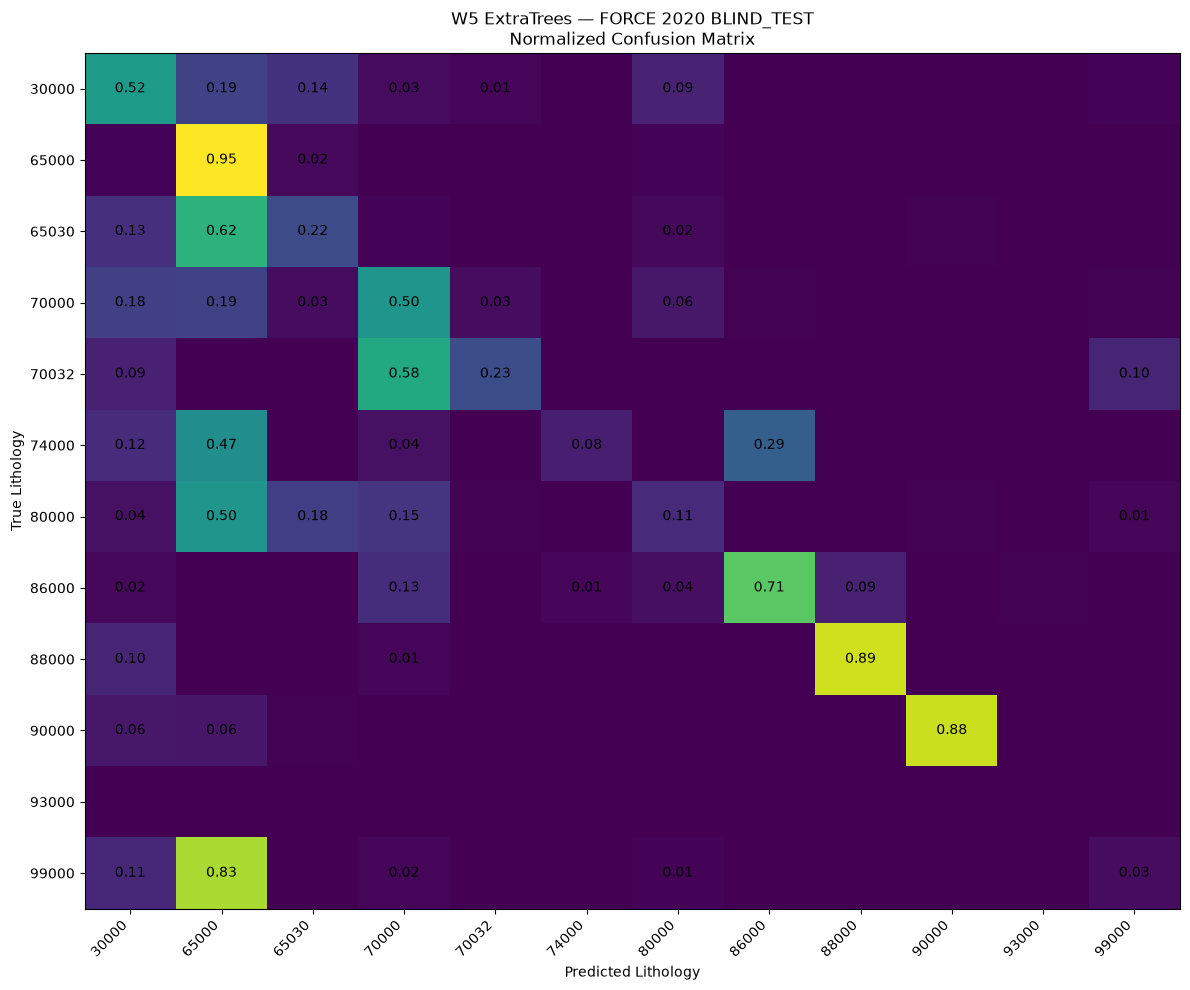

FINAL NORMALIZED CONFUSION MATRIX SAVED
../results/figures/final_blind_normalized_confusion_matrix.png


In [15]:
# ============================================================
# Cell 11 — FINAL BLIND_TEST NORMALIZED CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# 1. Compute confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_blind_final,
    y_blind_pred,
    labels=final_labels
)

# Normalize each row = recall for that lithology
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Avoid division-by-zero for classes with no true samples
cm_normalized = np.nan_to_num(cm_normalized)

# ------------------------------------------------------------
# 2. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    cm_normalized,
    interpolation="nearest",
    aspect="auto"
)

ax.set_title(
    "W5 ExtraTrees — FORCE 2020 BLIND_TEST\n"
    "Normalized Confusion Matrix"
)

ax.set_xlabel("Predicted Lithology")
ax.set_ylabel("True Lithology")

class_names = [str(int(x)) for x in final_labels]

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

# ------------------------------------------------------------
# 3. Add percentages inside cells
# ------------------------------------------------------------

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):

        value = cm_normalized[i, j]

        if value >= 0.01:
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

plt.tight_layout()

# ------------------------------------------------------------
# 4. Save figure
# ------------------------------------------------------------

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

figure_path = (
    FIGURES_DIR /
    "final_blind_normalized_confusion_matrix.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 65)
print("FINAL NORMALIZED CONFUSION MATRIX SAVED")
print("=" * 65)
print(figure_path)

Most important confusion patterns
The matrix gives a very clear geological/ML story:
65030 → 65000
62% of true Sandstone/Shale samples are predicted as Shale, while only 22% are correctly identified.

99000 → 65000
83% of true Tuff samples are predicted as Shale.

80000 → 65000
50% of Marl samples are predicted as Shale.

74000 → 65000
47% of Dolomite samples are predicted as Shale.

70032 → 70000
58% of Chalk samples are predicted as Limestone.

One important observation
Your model isn't simply "bad at rare classes." It successfully identifies some rare lithologies:
- Halite: 89% recall
- Anhydrite: 71%
- Coal: 88%

So the problem is more nuanced: class separability depends on how distinctive the available well-log responses are, in addition to class frequency.
Also, 93000 Basement has no true samples in the blind set, so its blank row is expected 

In [16]:
# ============================================================
# Cell 12 — OFFICIAL FORCE 2020 PENALTY SCORE
# ============================================================

import numpy as np

# FORCE 2020 class order
FORCE_LABEL_ORDER = [
    30000,  # Sandstone
    65030,  # Sandstone/Shale
    65000,  # Shale
    80000,  # Marl
    74000,  # Dolomite
    70000,  # Limestone
    70032,  # Chalk
    88000,  # Halite
    86000,  # Anhydrite
    99000,  # Tuff
    90000,  # Coal
    93000   # Basement
]

# Official FORCE 2020 penalty matrix
FORCE_PENALTY_MATRIX = np.array([
    [0,     2,     3.5,   3,     3.75,  3.5,   3.5,   4,     4,     2.5,   3.875, 3.25],
    [2,     0,     2.375, 2.75,  4,     3.75,  3.75,  3.875, 4,     3,     3.75,  3],
    [3.5,   2.375, 0,     2,     3.5,   3.5,   3.75,  4,     4,     2.75,  3.25,  3],
    [3,     2.75,  2,     0,     2.5,   2,     2.25,  4,     4,     3.375, 3.75,  3.25],
    [3.75,  4,     3.5,   2.5,   0,     2.625, 2.875, 3.75,  3.25,  3,     4,     3.625],
    [3.5,   3.75,  3.5,   2,     2.625, 0,     1.375, 4,     3.75,  3.5,   4,     3.625],
    [3.5,   3.75,  3.75,  2.25,  2.875, 1.375, 0,     4,     3.75,  3.125, 4,     3.75],
    [4,     3.875, 4,     4,     3.75,  4,     4,     0,     2.75,  3.75,  3.75,  4],
    [4,     4,     4,     4,     3.25, 3.75, 3.75, 2.75,  0,     4,     4,     3.875],
    [2.5,   3,     2.75,  3.375, 3,     3.5,   3.125, 3.75,  4,     0,     2.5,   3.25],
    [3.875, 3.75,  3.25,  3.75,  4,     4,     4,     3.75,  4,     2.5,   0,     4],
    [3.25,  3,     3,     3.25,  3.625, 3.625, 3.75,  4,     3.875, 3.25,  4,     0]
])

# Convert lithology code -> FORCE matrix index
force_index = {
    label: i
    for i, label in enumerate(FORCE_LABEL_ORDER)
}

true_idx = np.array([
    force_index[int(x)]
    for x in y_blind_final
])

pred_idx = np.array([
    force_index[int(x)]
    for x in y_blind_pred
])

# Penalty for every individual prediction
penalties = FORCE_PENALTY_MATRIX[true_idx, pred_idx]

# Official FORCE-style score
force_blind_score = -np.mean(penalties)

print("=" * 65)
print("FINAL W5 — FORCE 2020 STYLE BLIND SCORE")
print("=" * 65)

print(f"FORCE Blind Score: {force_blind_score:.6f}")
print(f"Mean Penalty:      {np.mean(penalties):.6f}")
print(f"Samples:           {len(penalties):,}")

print("\nComparison:")
print(f"Accuracy:          {blind_accuracy:.6f}")
print(f"Balanced Accuracy: {blind_balanced_accuracy:.6f}")
print(f"Macro F1:          {blind_macro_f1:.6f}")
print(f"Weighted F1:       {blind_weighted_f1:.6f}")
print(f"FORCE Score:       {force_blind_score:.6f}")

FINAL W5 — FORCE 2020 STYLE BLIND SCORE
FORCE Blind Score: -0.687657
Mean Penalty:      0.687657
Samples:           122,576

Comparison:
Accuracy:          0.738211
Balanced Accuracy: 0.466030
Macro F1:          0.436673
Weighted F1:       0.713523
FORCE Score:       -0.687657
